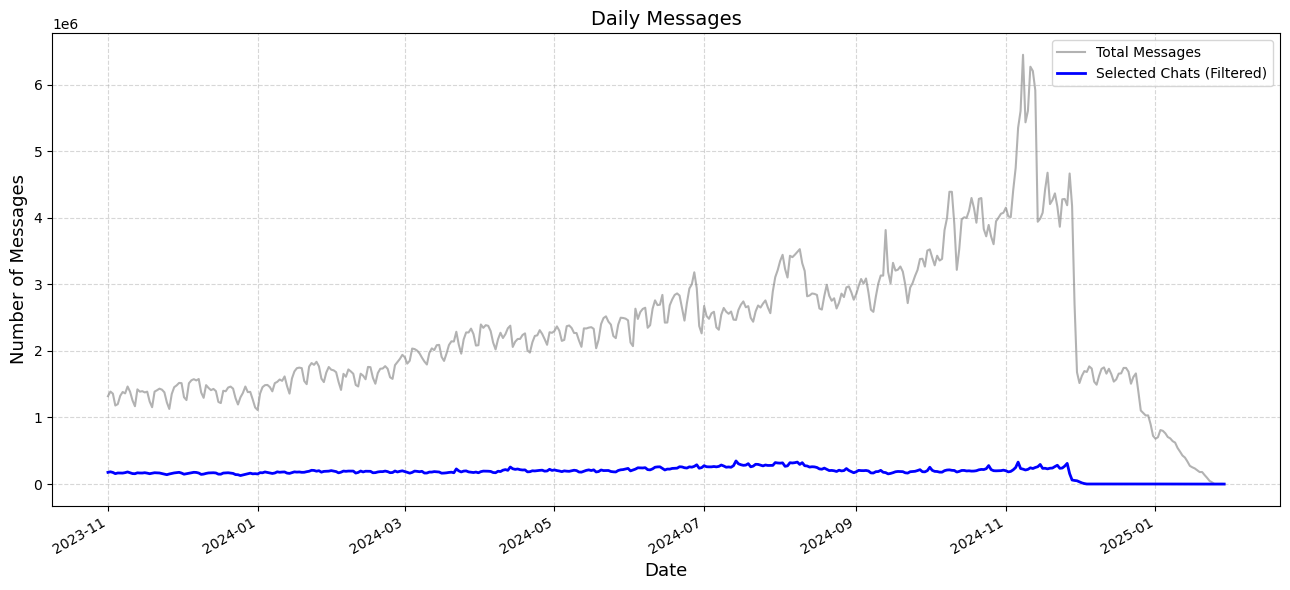

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json("relatorio_diario.json", orient='index')
df.index = pd.to_datetime(df.index)
df = df[df.index >= '2023-01-01']
df = df.sort_index()

plt.figure(figsize=(13, 6))
plt.plot(df.index, df['total'], label='Total Messages', color='gray', alpha=0.6)
plt.plot(df.index, df['filtrado'], label='Selected Chats (Filtered)', color='blue', linewidth=2)

plt.title('Daily Messages', fontsize=14)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Number of Messages', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.savefig("grafico_2023_2024.png", dpi=300)
plt.show()

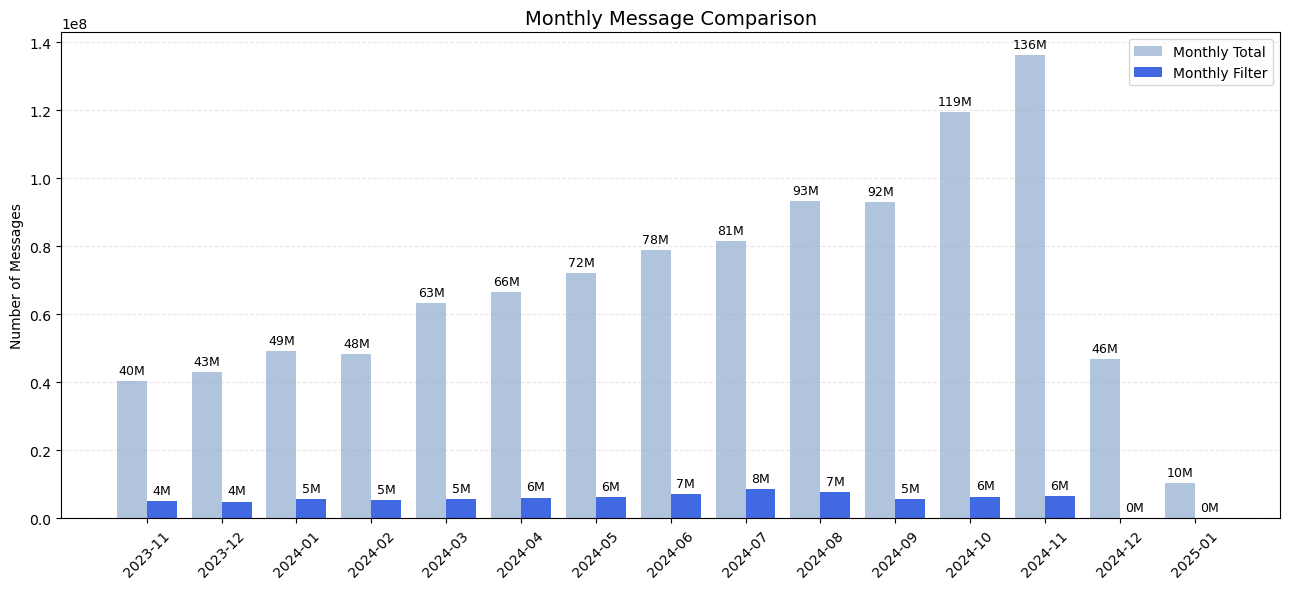

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import json

with open("relatorio_mensagens.json", "r") as f:
    mensal_data = json.load(f)

df_mensal = pd.DataFrame.from_dict(mensal_data, orient='index')
df_mensal = df_mensal[df_mensal.index >= '2023-11'].sort_index()

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(df_mensal))
largura = 0.4

# Criar as barras
barras_total = ax.bar([i - largura/2 for i in x], df_mensal['total'], 
                      width=largura, label='Monthly Total', color='lightsteelblue')

barras_filtrado = ax.bar([i + largura/2 for i in x], df_mensal['filtrado'], 
                         width=largura, label='Monthly Filter', color='royalblue')

def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height/1e6)}M', # Mostra em Milhões (M)
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(barras_total)
add_labels(barras_filtrado)

# 5. Estilização
ax.set_title('Monthly Message Comparison', fontsize=14)
ax.set_ylabel('Number of Messages')
ax.set_xticks(x)
ax.set_xticklabels(df_mensal.index, rotation=45)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("comparativo_mensal_barras.png", dpi=300)
plt.show()

In [17]:
import pandas as pd
import numpy as np

# 1. Carregar os dados
df = pd.read_json("relatorio_diario.json", orient='index')
df.index = pd.to_datetime(df.index)

df.head()

,total,filtrado
2019-08-01,17,0
2019-08-07,4,0
2023-11-01,1320288,175946
2023-11-02,1389388,184302
2023-11-03,1358310,174940


In [16]:

# 2. Filtrar o período (mantendo a consistência com o gráfico de 2023-11 em diante)
df_periodo = df[df.index >= '2023-11-01']

# 3. Calcular Estatísticas para o Total e para o Filtrado
stats = {}
for col in ['total', 'filtrado']:
    stats[col] = {
        'soma': df_periodo[col].sum(),
        'media': df_periodo[col].mean(),
        'variancia': df_periodo[col].var(),
        'desvio_padrao': df_periodo[col].std() # O desvio padrão é a raiz da variância, mais fácil de interpretar
    }

# 4. Exibir de forma formatada para o relatório
print("=== ESTATÍSTICAS DO RELATÓRIO (Desde Nov/2023) ===")
for grupo, valores in stats.items():
    print(f"\nGRUPO: {grupo.upper()}")
    print(f"  - Contagem Total: {valores['soma']:,.0f}")
    print(f"  - Média Diária: {valores['media']:,.2f}")
    print(f"  - Variância: {valores['variancia']:,.2f}")
    print(f"  - Desvio Padrão: {valores['desvio_padrao']:,.2f}")

=== ESTATÍSTICAS DO RELATÓRIO (Desde Nov/2023) ===

GRUPO: TOTAL
  - Contagem Total: 1,042,231,029 (1042.23 Milhões)
  - Média Diária: 2,285,594.36
  - Variância: 1,157,330,636,638.45
  - Desvio Padrão: 1,075,793.03

GRUPO: FILTRADO
  - Contagem Total: 81,167,770 (81.17 Milhões)
  - Média Diária: 177,999.50
  - Variância: 6,350,295,867.18
  - Desvio Padrão: 79,688.74


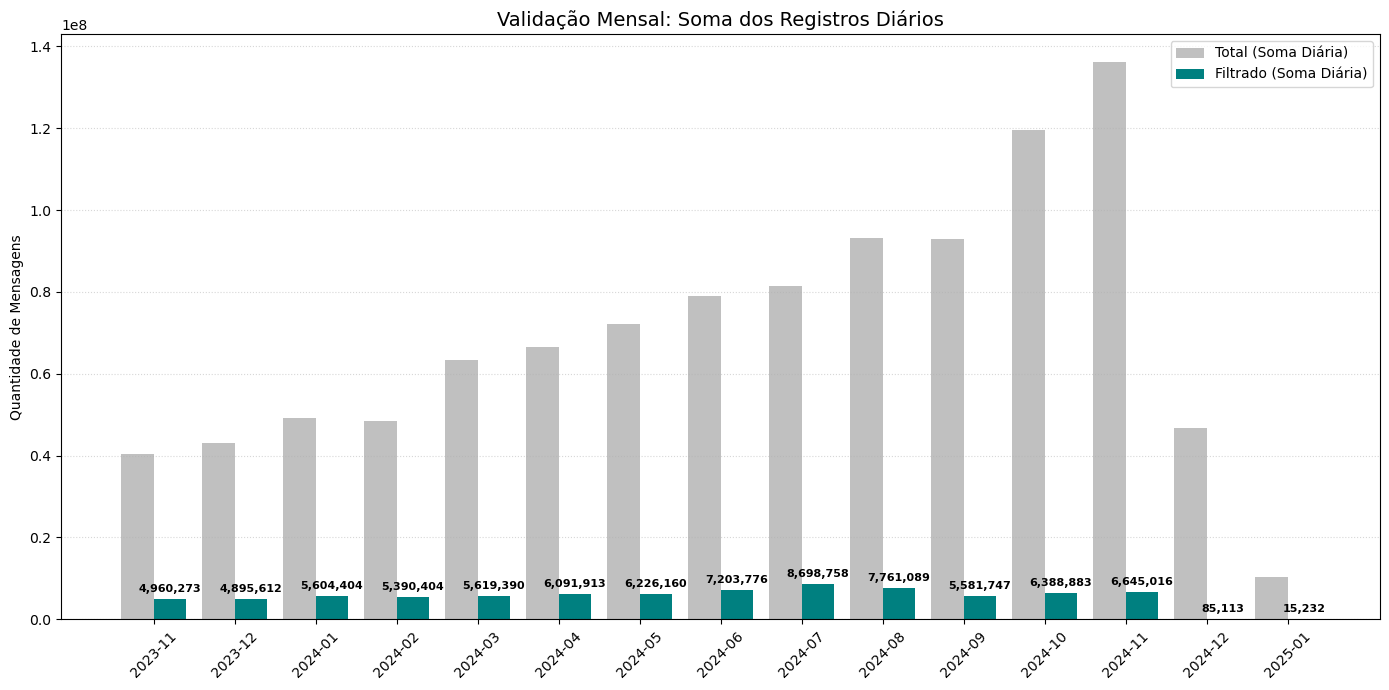

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar o relatório diário
df_diario = pd.read_json("relatorio_diario.json", orient='index')
df_diario.index = pd.to_datetime(df_diario.index)

# 2. Agrupar por mês e somar os valores
# O 'MS' garante que o agrupamento seja feito pelo início do mês
df_mensal_agrupado = df_diario.resample('MS').sum()

# 3. Filtrar para focar no período de interesse (removendo 2019)
df_mensal_agrupado = df_mensal_agrupado[df_mensal_agrupado.index >= '2023-11-01']

# 4. Configurar o gráfico de barras
fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(df_mensal_agrupado))
largura = 0.4

# Barras Total vs Filtrado
ax.bar([i - largura/2 for i in x], df_mensal_agrupado['total'], 
       width=largura, label='Total (Soma Diária)', color='silver')

ax.bar([i + largura/2 for i in x], df_mensal_agrupado['filtrado'], 
       width=largura, label='Filtrado (Soma Diária)', color='teal')

# 5. Adicionar rótulos para conferência (conforme image_8410ba.png)
for i, (idx, row) in enumerate(df_mensal_agrupado.iterrows()):
    # Exibe o valor exato acima da barra do Filtrado para comparar com o JSON
    ax.annotate(f"{int(row['filtrado']):,}", 
                xy=(i + largura/2, row['filtrado']),
                xytext=(0, 5), textcoords="offset points",
                ha='center', fontsize=8, fontweight='bold')

# Estilização do gráfico
ax.set_title('Validação Mensal: Soma dos Registros Diários', fontsize=14)
ax.set_ylabel('Quantidade de Mensagens')
ax.set_xticks(x)
# Formata o rótulo do eixo X para YYYY-MM
ax.set_xticklabels([dt.strftime('%Y-%m') for dt in df_mensal_agrupado.index], rotation=45)
ax.legend()

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("validacao_mensal_agrupada.png", dpi=300)
plt.show()

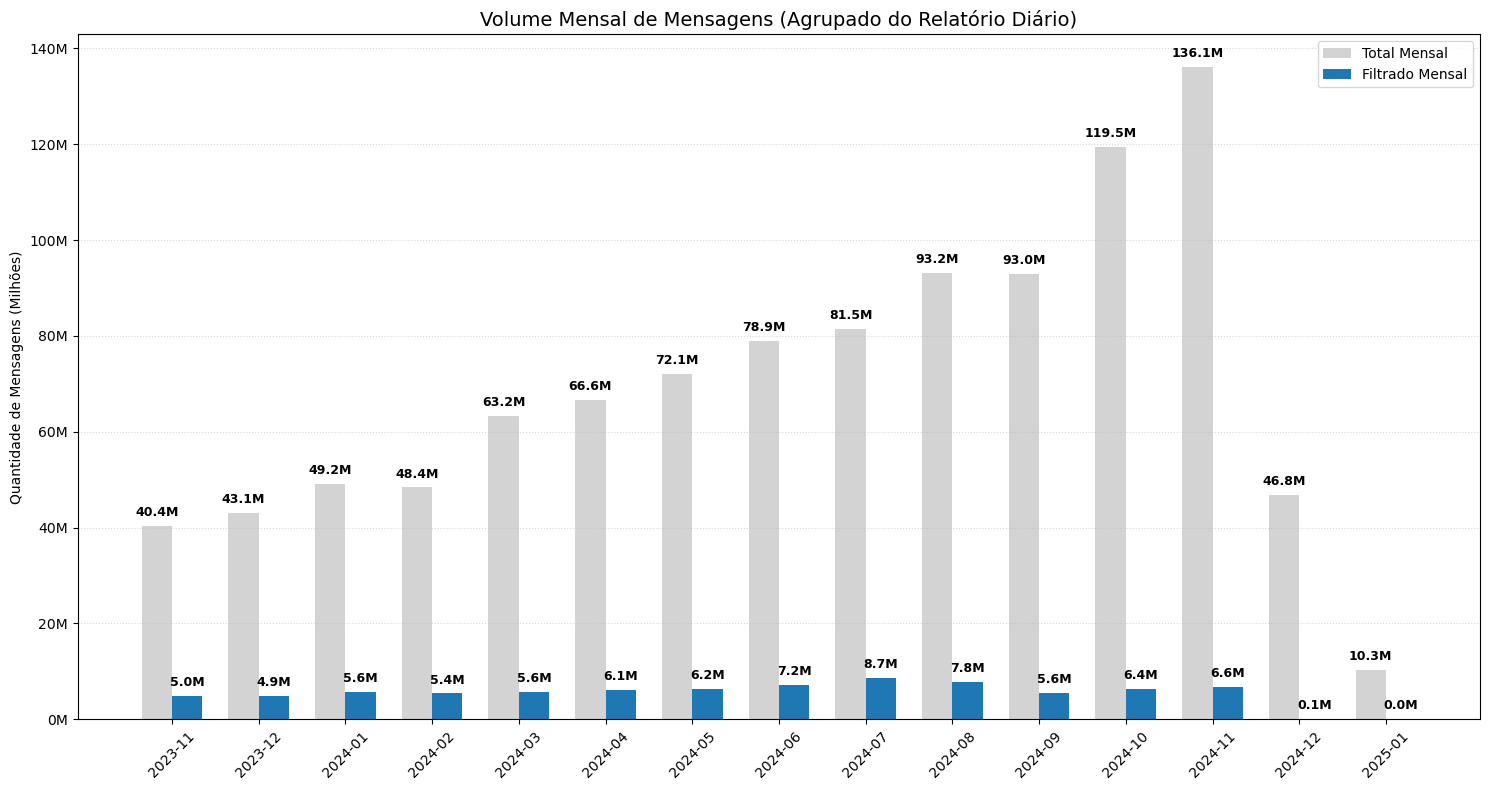

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar o relatório diário
df_diario = pd.read_json("relatorio_diario.json", orient='index')
df_diario.index = pd.to_datetime(df_diario.index)

# 2. Agrupar por mês e somar (Resample pela frequência 'MS' - Month Start)
df_mensal_agrupado = df_diario.resample('MS').sum()

# 3. Filtrar para focar no período de interesse (removendo 2019)
df_mensal_agrupado = df_mensal_agrupado[df_mensal_agrupado.index >= '2023-11-01']

# 4. Configurar o gráfico de barras
fig, ax = plt.subplots(figsize=(15, 8))
x = range(len(df_mensal_agrupado))
largura = 0.35

# Criar barras lado a lado
barras_total = ax.bar([i - largura/2 for i in x], df_mensal_agrupado['total'], 
                      width=largura, label='Total Mensal', color='#D3D3D3')

barras_filtrado = ax.bar([i + largura/2 for i in x], df_mensal_agrupado['filtrado'], 
                         width=largura, label='Filtrado Mensal', color='#1f77b4')

# 5. Função para formatar e adicionar os rótulos (6.423.423 -> 6.4M)
def add_labels_millions(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            # Formata para milhões com uma casa decimal
            label = f'{height/1e6:.1f}M'
            ax.annotate(label,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels_millions(barras_total)
add_labels_millions(barras_filtrado)

# 6. Estilização final
ax.set_title('Volume Mensal de Mensagens (Agrupado do Relatório Diário)', fontsize=14)
ax.set_ylabel('Quantidade de Mensagens (Milhões)')
ax.set_xticks(x)
ax.set_xticklabels([dt.strftime('%Y-%m') for dt in df_mensal_agrupado.index], rotation=45)
ax.legend()

# Remove a escala científica do eixo Y para ficar mais limpo
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("validacao_mensal_milhoes.png", dpi=300)
plt.show()